# Thesis Results Generator — Acoustic Drone Detection

This notebook regenerates thesis-ready **tables, figures, confusion matrices, ROC/PR curves, threshold sweeps, feature examples, augmentation examples, and model comparison plots** without retraining the CNN-Transformer.

It assumes your trained model and cached waveform windows are in Google Drive under:

`/content/drive/MyDrive/drone_audio_processed`

Main output folder:

`/content/drive/MyDrive/drone_audio_processed/thesis_results`

Run the notebook from top to bottom. The first run may take time because it evaluates the saved model and caches prediction arrays. Later runs reuse the saved predictions and regenerate figures quickly.

**Patch note:** This fixed version includes a mixed-precision-safe `AttentionPooling` loader for the saved CNN-Transformer model.


## 1. Install packages

This cell is safe to run in Colab. If the packages are already installed, it will finish quickly.

In [1]:
!pip -q install librosa numpy scikit-learn tensorflow pandas scipy matplotlib requests

## 2. Imports, paths, and configuration

Edit the paths here only if your Google Drive folder or model names are different.

In [2]:
import os, glob, json, zipfile, time, warnings, shutil, math
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score
)
import requests

warnings.filterwarnings('ignore')

# Mount Google Drive when running in Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False
    print('Not running in Colab, or Google Drive is already mounted/unavailable.')

# ---------------------------------------------------------------------
# Main project paths
# ---------------------------------------------------------------------
OUT_DIR = '/content/drive/MyDrive/drone_audio_processed'
THESIS_DIR = os.path.join(OUT_DIR, 'thesis_results')
FIG_DIR = os.path.join(THESIS_DIR, 'figures')
TABLE_DIR = os.path.join(THESIS_DIR, 'tables')
PRED_DIR = os.path.join(THESIS_DIR, 'predictions')
for d in [THESIS_DIR, FIG_DIR, TABLE_DIR, PRED_DIR]:
    os.makedirs(d, exist_ok=True)

# Cached waveform windows from the training notebook.
NPZ_PATH = os.path.join(OUT_DIR, 'waveform_0.50s_hop0.25s_recordsplit.npz')

# Saved CNN-Transformer v2 model.
CNN_TF_MODEL_PATH = os.path.join(OUT_DIR, 'model_cnntransformer_v2_improved.keras')

# Optional: update this if you have a saved LWCNN model and want to evaluate it too.
LWCNN_MODEL_PATH = None  # example: os.path.join(OUT_DIR, 'model_lwcnn_v3.keras')

# ---------------------------------------------------------------------
# Audio / feature constants used in your notebook
# ---------------------------------------------------------------------
SEED = 42
SR_TARGET = 16000
WIN_S = 0.5
HOP_S = 0.25
N_MELS = 64
N_FFT = 512
HOP_LENGTH = 128
FMAX = 8000
TOP_DB = 80
N_FRAMES = int(np.ceil(WIN_S * SR_TARGET / HOP_LENGTH))
INPUT_SHAPE = (N_MELS, N_FRAMES, 1)
BATCH = 64

# Evaluation / augmentation settings.
# Set INTERNAL_NOISY_EVAL=False if you want a clean internal test evaluation instead.
INTERNAL_NOISY_EVAL = True
EXTERNAL_STANDARD_USES_NOISE = True  # matches the current v2 notebook behaviour
TTA_N_AUGMENTS = 5
AUG_PROB = 0.7
SNR_MIN = -5.0
SNR_MAX = 20.0
FREQ_MASK_MAX = 8
TIME_MASK_MAX = 8
TIME_STRETCH_MIN = 0.80
TIME_STRETCH_MAX = 1.25
THRESHOLDS = np.round(np.arange(0.05, 0.96, 0.05), 2)

# External Svanström dataset download.
EXT_ROOT = '/content/external_drone_thesis'
EXT_ZIP_URL = 'https://codeload.github.com/DroneDetectionThesis/Drone-detection-dataset/zip/refs/heads/master'

# DEMAND noise source from your notebook. If this folder already exists, it will be reused.
DEMAND_DIR = '/content/DEMAND'
DEMAND_ZENODO_BASE = 'https://zenodo.org/records/1227121/files'
DEMAND_16K_ENVS = [
    'DKITCHEN','DLIVING','DWASHING','NFIELD','NPARK','NRIVER',
    'OHALLWAY','OMEETING','OOFFICE','PCAFETER','PRESTO','PSTATION',
    'SPSQUARE','STRAFFIC','TBUS','TCAR','TMETRO'
]

# Thesis figure style.
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9,
})

rng = np.random.default_rng(SEED)
tf.random.set_seed(SEED)
print('Configuration loaded.')
print('Input shape:', INPUT_SHAPE)
print('Output folder:', THESIS_DIR)

Mounted at /content/drive
Configuration loaded.
Input shape: (64, 63, 1)
Output folder: /content/drive/MyDrive/drone_audio_processed/thesis_results


## 3. Helper functions

These functions handle feature extraction, plotting, metrics, saved-model loading, threshold sweeps, and file exports.

In [27]:
def save_fig(fig, name, tight=True):
    """Save a figure as PNG and PDF for thesis insertion."""
    if tight:
        fig.tight_layout()
    png_path = os.path.join(FIG_DIR, name if name.endswith('.png') else name + '.png')
    pdf_path = png_path.replace('.png', '.pdf')
    fig.savefig(png_path, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print('Saved:', png_path)
    print('Saved:', pdf_path)
    return png_path, pdf_path


def save_table(df, name):
    """Save a dataframe as CSV and Excel."""
    csv_path = os.path.join(TABLE_DIR, name if name.endswith('.csv') else name + '.csv')
    xlsx_path = csv_path.replace('.csv', '.xlsx')
    df.to_csv(csv_path, index=False)
    try:
        df.to_excel(xlsx_path, index=False)
    except Exception as e:
        print('Excel export skipped:', e)
    print('Saved:', csv_path)
    return csv_path


def log_mel_db(y, sr=SR_TARGET):
    y = np.asarray(y, dtype=np.float32)
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT,
        hop_length=HOP_LENGTH, fmax=FMAX, power=2.0
    )
    return librosa.power_to_db(mel, ref=1.0, top_db=TOP_DB).astype(np.float32)


def mel_to_model_array(mel):
    mel = mel[..., None].astype(np.float32)
    return ((mel - np.mean(mel)) / (np.std(mel) + 1e-6)).astype(np.float32)


def rms(x):
    return np.sqrt(np.mean(np.asarray(x, dtype=np.float32) ** 2) + 1e-12)


def add_real_noise_snr(y, noise_bank, snr_db, rl):
    y = np.asarray(y, dtype=np.float32)
    if len(noise_bank) == 0:
        return y
    nb = noise_bank[rl.integers(0, len(noise_bank))]
    n = len(y)
    if len(nb) >= n:
        s = rl.integers(0, len(nb) - n + 1)
        nb = nb[s:s+n]
    else:
        nb = np.tile(nb, int(np.ceil(n / len(nb))))[:n]
    noise_scaled = nb * (rms(y) / (10 ** (snr_db / 20.0)) / (rms(nb) + 1e-12))
    y_noisy = y + noise_scaled
    peak = np.max(np.abs(y_noisy))
    return (y_noisy / peak).astype(np.float32) if peak > 1.0 else y_noisy.astype(np.float32)


def windows_all(y, sr=SR_TARGET, win_s=WIN_S, hop_s=HOP_S):
    y = np.asarray(y, dtype=np.float32)
    win = int(round(win_s * sr))
    hop = int(round(hop_s * sr))
    if len(y) <= win:
        out = np.zeros(win, dtype=np.float32)
        start = max(0, (win - len(y)) // 2)
        out[start:start+len(y)] = y
        return [out]
    return [y[s:s+win] for s in range(0, len(y) - win + 1, hop)]


def format_pct(x):
    return f'{100*x:.2f}%'


def drone_metrics(y_true, y_prob, threshold):
    pred = (np.asarray(y_prob) >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)
    acc = (tp + tn) / max(1, cm.sum())
    return {
        'threshold': threshold,
        'accuracy': acc,
        'precision_drone': precision,
        'recall_drone': recall,
        'f1_drone': f1,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
    }


def make_metrics_row(model_name, y_true, y_prob, threshold=0.5, dataset='Internal'):
    m = drone_metrics(y_true, y_prob, threshold)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = np.nan
    try:
        ap = average_precision_score(y_true, y_prob)
    except Exception:
        ap = np.nan
    return {
        'Model': model_name,
        'Dataset': dataset,
        'Threshold': threshold,
        'Accuracy': m['accuracy'],
        'ROC AUC': auc,
        'Average Precision': ap,
        'Drone Precision': m['precision_drone'],
        'Drone Recall': m['recall_drone'],
        'Drone F1': m['f1_drone'],
        'TN': m['tn'], 'FP': m['fp'], 'FN': m['fn'], 'TP': m['tp'],
    }


def threshold_sweep(y_true_internal, y_prob_internal, y_true_external, y_prob_external, model_name='CNN-Transformer v2'):
    rows = []
    for t in THRESHOLDS:
        im = drone_metrics(y_true_internal, y_prob_internal, t)
        em = drone_metrics(y_true_external, y_prob_external, t)
        combined = 2 * im['f1_drone'] * em['recall_drone'] / (im['f1_drone'] + em['recall_drone'] + 1e-12)
        rows.append({
            'Model': model_name,
            'Threshold': t,
            'Internal Drone F1': im['f1_drone'],
            'External Drone Recall': em['recall_drone'],
            'External Drone F1': em['f1_drone'],
            'Combined Score': combined,
            'Internal FP': im['fp'],
            'Internal FN': im['fn'],
            'External FP': em['fp'],
            'External FN': em['fn'],
        })
    return pd.DataFrame(rows)


def plot_cm(cm, title, ax):
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Count')

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['No drone', 'Drone'])
    ax.set_yticklabels(['No drone', 'Drone'])
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_title(title)

    row_sums = cm.sum(axis=1, keepdims=True)
    thresh = cm.max() / 2.0 if cm.max() else 0
    labels = np.array([['TN', 'FP'], ['FN', 'TP']])

    for i in range(2):
        for j in range(2):
            pct = cm[i, j] / row_sums[i, 0] * 100 if row_sums[i, 0] else 0
            colour = 'white' if cm[i, j] > thresh else 'black'

            ax.text(j, i - 0.18, labels[i, j],
                    ha='center', va='center',
                    color=colour, fontweight='bold')

            ax.text(j, i, f'{cm[i, j]:,}',
                    ha='center', va='center',
                    color=colour, fontweight='normal')

            ax.text(j, i + 0.18, f'{pct:.1f}%',
                    ha='center', va='center',
                    color=colour, fontweight='normal')


@tf.keras.utils.register_keras_serializable(package='Custom')
class AttentionPooling(layers.Layer):
    """Custom layer needed to load model_cnntransformer_v2_improved.keras.

    This version is safe under mixed precision. The original training layer can
    produce float16 activations and float32 attention weights during model
    deserialisation; the explicit casts below avoid the float16/float32 multiply
    error when loading a saved .keras model.
    """
    def __init__(self, d_model=None, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.attn_vec = None
        self.attn_score = None

    def build(self, input_shape):
        dim = self.d_model or int(input_shape[-1])
        self.attn_vec = layers.Dense(dim, use_bias=True, activation='tanh')
        self.attn_score = layers.Dense(1, use_bias=False)
        self.attn_vec.build(input_shape)
        self.attn_score.build(self.attn_vec.compute_output_shape(input_shape))
        super().build(input_shape)

    def call(self, x, training=False):
        x_dtype = x.dtype
        scores = self.attn_score(self.attn_vec(x))
        scores = tf.cast(scores, tf.float32)          # stable softmax
        weights = tf.nn.softmax(scores, axis=1)
        weights = tf.cast(weights, x_dtype)           # match x before multiply
        return tf.reduce_sum(x * weights, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

    def get_config(self):
        config = super().get_config()
        config.update({'d_model': self.d_model})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)


def load_keras_model(model_path):
    if not os.path.exists(model_path):
        raise FileNotFoundError(f'Model not found: {model_path}')
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={'AttentionPooling': AttentionPooling},
        compile=False,
        safe_mode=False,
    )
    print('Loaded model:', model_path)
    print('Parameters:', f'{model.count_params():,}')
    return model

print('Helpers ready.')

Helpers ready.


## 4. Training curves without retraining

This cell uses the completed CNN-Transformer v2 training log from your existing notebook. It saves the curve data and exports a thesis-ready training curve figure.

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/tables/cnn_transformer_v2_training_history.csv
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_01_cnn_transformer_v2_training_curves.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_01_cnn_transformer_v2_training_curves.pdf


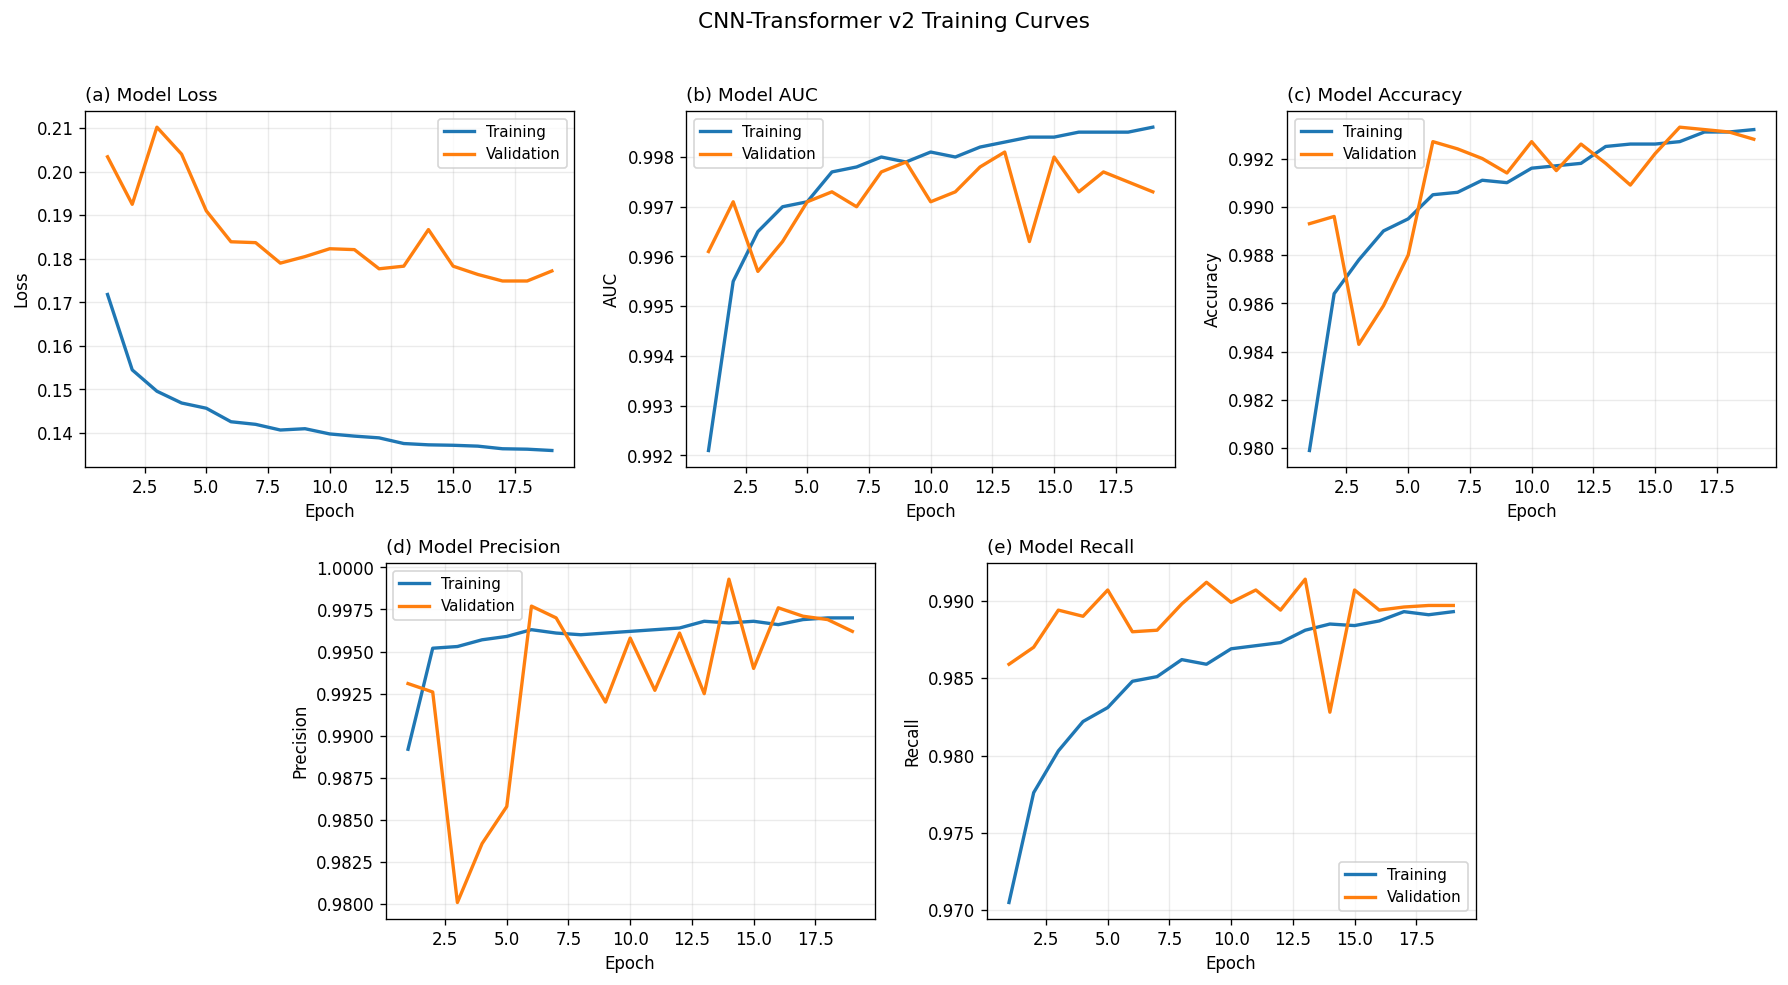

In [30]:
# Completed CNN-Transformer v2 training history recovered from your existing notebook output.
# This avoids retraining just to reproduce the training curves.
history_df = pd.DataFrame({
    'epoch': list(range(1, 20)),
    'accuracy': [0.9799, 0.9864, 0.9878, 0.9890, 0.9895, 0.9905, 0.9906, 0.9911, 0.9910, 0.9916, 0.9917, 0.9918, 0.9925, 0.9926, 0.9926, 0.9927, 0.9931, 0.9931, 0.9932],
    'auc': [0.9921, 0.9955, 0.9965, 0.9970, 0.9971, 0.9977, 0.9978, 0.9980, 0.9979, 0.9981, 0.9980, 0.9982, 0.9983, 0.9984, 0.9984, 0.9985, 0.9985, 0.9985, 0.9986],
    'loss': [0.1718, 0.1545, 0.1496, 0.1469, 0.1457, 0.1426, 0.1420, 0.1407, 0.1410, 0.1398, 0.1393, 0.1389, 0.1376, 0.1373, 0.1372, 0.1370, 0.1364, 0.1363, 0.1360],
    'precision': [0.9892, 0.9952, 0.9953, 0.9957, 0.9959, 0.9963, 0.9961, 0.9960, 0.9961, 0.9962, 0.9963, 0.9964, 0.9968, 0.9967, 0.9968, 0.9966, 0.9969, 0.9970, 0.9970],
    'recall': [0.9705, 0.9776, 0.9803, 0.9822, 0.9831, 0.9848, 0.9851, 0.9862, 0.9859, 0.9869, 0.9871, 0.9873, 0.9881, 0.9885, 0.9884, 0.9887, 0.9893, 0.9891, 0.9893],
    'val_accuracy': [0.9893, 0.9896, 0.9843, 0.9859, 0.9880, 0.9927, 0.9924, 0.9920, 0.9914, 0.9927, 0.9915, 0.9926, 0.9918, 0.9909, 0.9922, 0.9933, 0.9932, 0.9931, 0.9928],
    'val_auc': [0.9961, 0.9971, 0.9957, 0.9963, 0.9971, 0.9973, 0.9970, 0.9977, 0.9979, 0.9971, 0.9973, 0.9978, 0.9981, 0.9963, 0.9980, 0.9973, 0.9977, 0.9975, 0.9973],
    'val_loss': [0.2034, 0.1925, 0.2102, 0.2040, 0.1910, 0.1839, 0.1837, 0.1790, 0.1805, 0.1823, 0.1821, 0.1777, 0.1783, 0.1867, 0.1783, 0.1764, 0.1749, 0.1749, 0.1772],
    'val_precision': [0.9931, 0.9926, 0.9801, 0.9836, 0.9858, 0.9977, 0.9970, 0.9945, 0.9920, 0.9958, 0.9927, 0.9961, 0.9925, 0.9993, 0.9940, 0.9976, 0.9971, 0.9969, 0.9962],
    'val_recall': [0.9859, 0.9870, 0.9894, 0.9890, 0.9907, 0.9880, 0.9881, 0.9898, 0.9912, 0.9899, 0.9907, 0.9894, 0.9914, 0.9828, 0.9907, 0.9894, 0.9896, 0.9897, 0.9897],
    'learning_rate': [1e-4, 1e-4, 1e-4, 1e-4, 1e-4, 5e-5, 5e-5, 5e-5, 5e-5, 5e-5, 5e-5, 5e-5, 2.5e-5, 2.5e-5, 2.5e-5, 2.5e-5, 1.25e-5, 1.25e-5, 1.25e-5],
})

save_table(history_df, 'cnn_transformer_v2_training_history')

fig = plt.figure(figsize=(15, 8))
fig.subplots_adjust(hspace=0.45, wspace=0.35)

gs = fig.add_gridspec(2, 6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes = [ax1, ax2, ax3, ax4, ax5]

plot_items = [
    ('loss', 'Loss'),
    ('auc', 'AUC'),
    ('accuracy', 'Accuracy'),
    ('precision', 'Precision'),
    ('recall', 'Recall'),
]

for ax, (metric, title) in zip(axes, plot_items):
    ax.plot(history_df['epoch'], history_df[metric], linewidth=2, label='Training')
    ax.plot(history_df['epoch'], history_df[f'val_{metric}'], linewidth=2, label='Validation')
    ax.set_title(f'({chr(97 + plot_items.index((metric, title)))}) Model {title}', loc='left')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.grid(alpha=0.25)
    ax.legend()

fig.suptitle('CNN-Transformer v2 Training Curves', y=1.02, fontsize=13)
save_fig(fig, 'fig_01_cnn_transformer_v2_training_curves')
plt.show()

## 5. Load cached waveform windows

This uses the `.npz` file created during the original data-preparation run. It does **not** retrain or rebuild the dataset.

In [5]:
if not os.path.exists(NPZ_PATH):
    raise FileNotFoundError(
        f'Cached waveform file not found: {NPZ_PATH}\n'
        'Run the original preprocessing notebook first, or update NPZ_PATH.'
    )

cache = np.load(NPZ_PATH)
X_train_wav = cache['X_train_wav']
y_train_wav = cache['y_train_wav'].astype(int)
X_val_wav = cache['X_val_wav']
y_val_wav = cache['y_val_wav'].astype(int)
X_test_wav = cache['X_test_wav']
y_test_wav = cache['y_test_wav'].astype(int)

split_summary = pd.DataFrame([
    {'Split': 'Train', 'Windows': len(y_train_wav), 'Drone windows': int(y_train_wav.sum()), 'No-drone windows': int((y_train_wav == 0).sum())},
    {'Split': 'Validation', 'Windows': len(y_val_wav), 'Drone windows': int(y_val_wav.sum()), 'No-drone windows': int((y_val_wav == 0).sum())},
    {'Split': 'Internal test', 'Windows': len(y_test_wav), 'Drone windows': int(y_test_wav.sum()), 'No-drone windows': int((y_test_wav == 0).sum())},
])
split_summary['Drone fraction'] = split_summary['Drone windows'] / split_summary['Windows']
display(split_summary)
save_table(split_summary, 'table_dataset_window_split_summary')

,Split,Windows,Drone windows,No-drone windows,Drone fraction
0,Train,255488,127744,127744,0.500000
1,Validation,32731,16716,16015,0.510709
2,Internal test,32694,16881,15813,0.516333


Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/tables/table_dataset_window_split_summary.csv


'/content/drive/MyDrive/drone_audio_processed/thesis_results/tables/table_dataset_window_split_summary.csv'

## 6. Load/download DEMAND noise snippets

This is needed for the noisy internal evaluation and TTA plots. If the DEMAND files already exist in the Colab runtime, they are reused.

In [6]:
def ensure_demand_noise():
    os.makedirs(DEMAND_DIR, exist_ok=True)
    existing = glob.glob(os.path.join(DEMAND_DIR, '**', '*.wav'), recursive=True)
    if existing:
        print(f'Reusing existing DEMAND WAV files: {len(existing)}')
        return
    print('Downloading DEMAND 16 kHz environments...')
    for env in DEMAND_16K_ENVS:
        url = f'{DEMAND_ZENODO_BASE}/{env}_16k.zip?download=1'
        zip_path = f'/content/demand_{env.lower()}.zip'
        print(f'  {env}...', end=' ', flush=True)
        last_error = None
        for attempt in range(3):
            try:
                r = requests.get(url, stream=True, timeout=120)
                r.raise_for_status()
                with open(zip_path, 'wb') as f:
                    for chunk in r.iter_content(1024 * 1024):
                        if chunk:
                            f.write(chunk)
                with zipfile.ZipFile(zip_path) as z:
                    z.extractall(DEMAND_DIR)
                os.remove(zip_path)
                print('done')
                break
            except Exception as e:
                last_error = e
                time.sleep(5)
        else:
            print('failed')
            raise RuntimeError(f'Could not download {env}: {last_error}')


def build_noise_bank():
    ensure_demand_noise()
    noise_bank = []
    seg_n = int(3.0 * SR_TARGET)
    wavs = glob.glob(os.path.join(DEMAND_DIR, '**', '*.wav'), recursive=True)
    for p in wavs:
        try:
            y, fs = librosa.load(p, sr=None, mono=True)
            if fs != SR_TARGET:
                y = librosa.resample(y, orig_sr=fs, target_sr=SR_TARGET)
            for s in range(0, len(y) - seg_n + 1, seg_n):
                seg = y[s:s+seg_n].astype(np.float32)
                if np.max(np.abs(seg)) > 1e-4:
                    noise_bank.append(seg)
        except Exception:
            pass
    return noise_bank

noise_bank = build_noise_bank()
print(f'Noise bank segments: {len(noise_bank):,}')

  DKITCHEN... done
  DLIVING... done
  DWASHING... done
  NFIELD... done
  NPARK... done
  NRIVER... done
  OHALLWAY... done
  OMEETING... done
  OOFFICE... done
  PCAFETER... done
  PRESTO... done
  PSTATION... done
  SPSQUARE... done
  STRAFFIC... done
  TBUS... done
  TCAR... done
  TMETRO... done
Noise bank segments: 27,200


## 7. Thesis feature and augmentation figures

These figures are useful for the Methodology chapter: waveform, STFT, mel/log-mel, noise injection, SpecAugment, time stretching, and mixup.

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_02_feature_extraction_examples.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_02_feature_extraction_examples.pdf


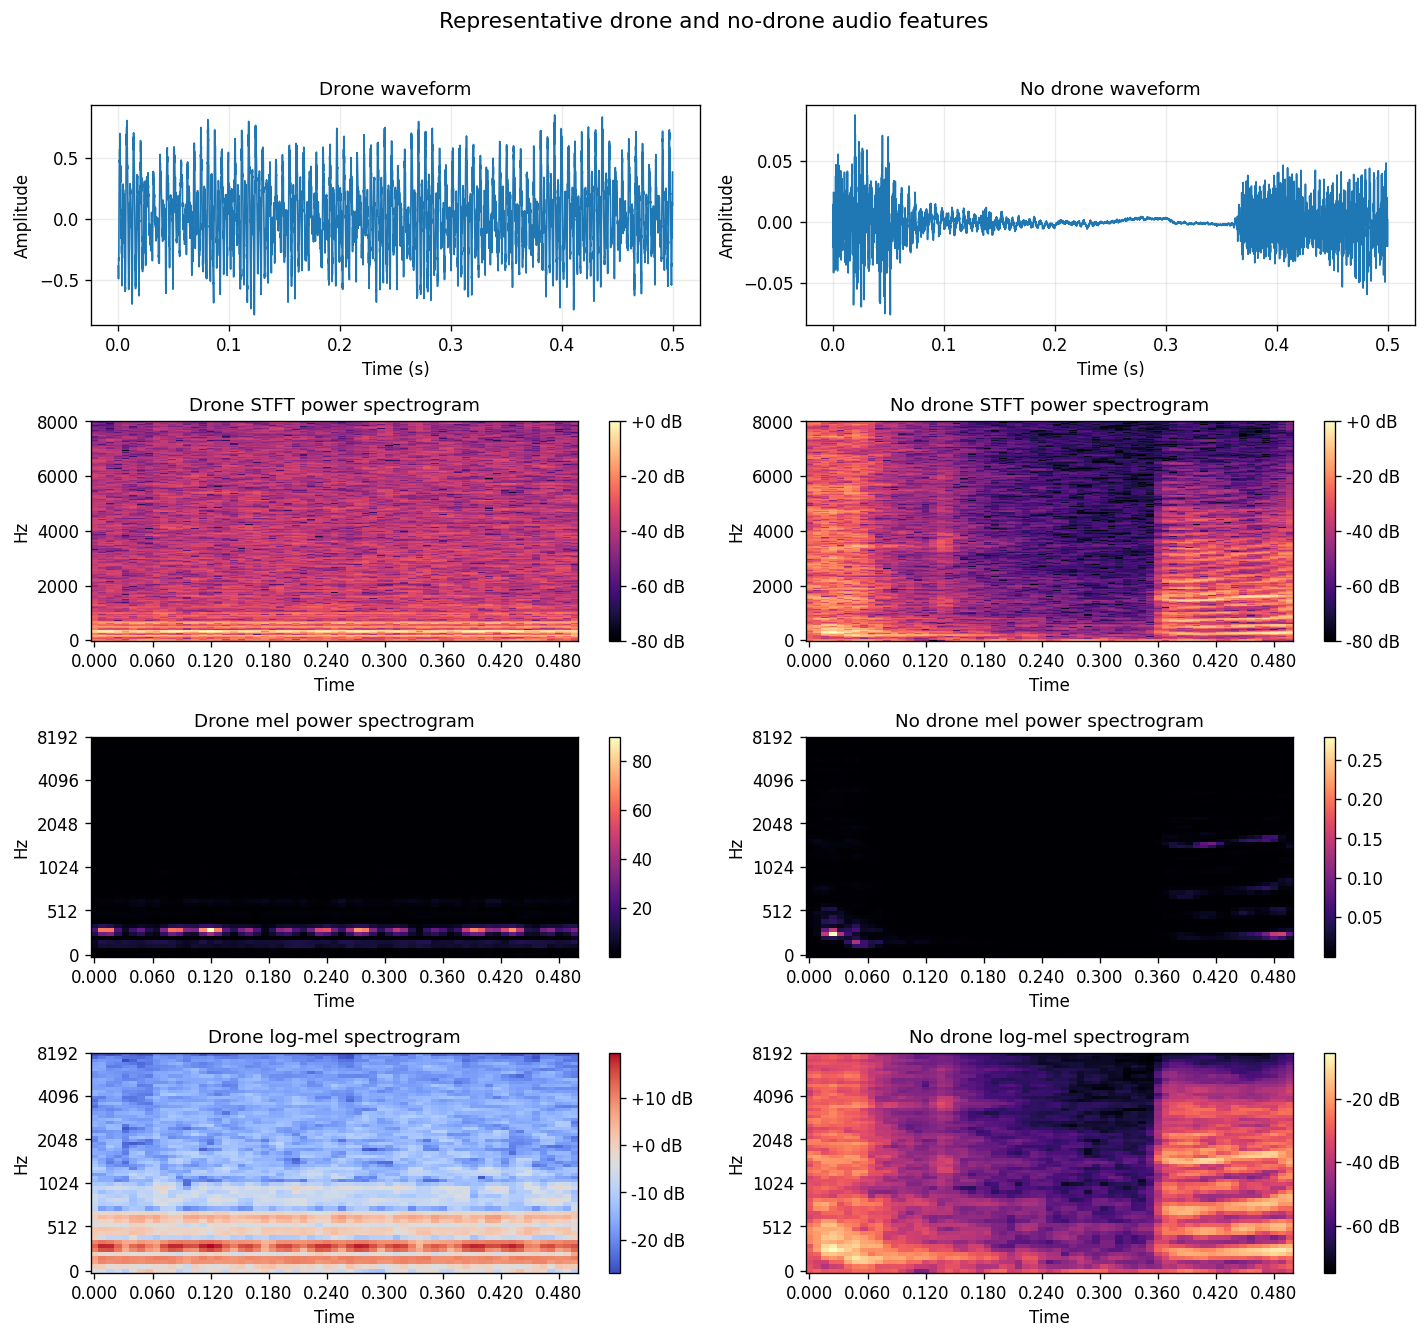

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_03_augmentation_examples.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_03_augmentation_examples.pdf


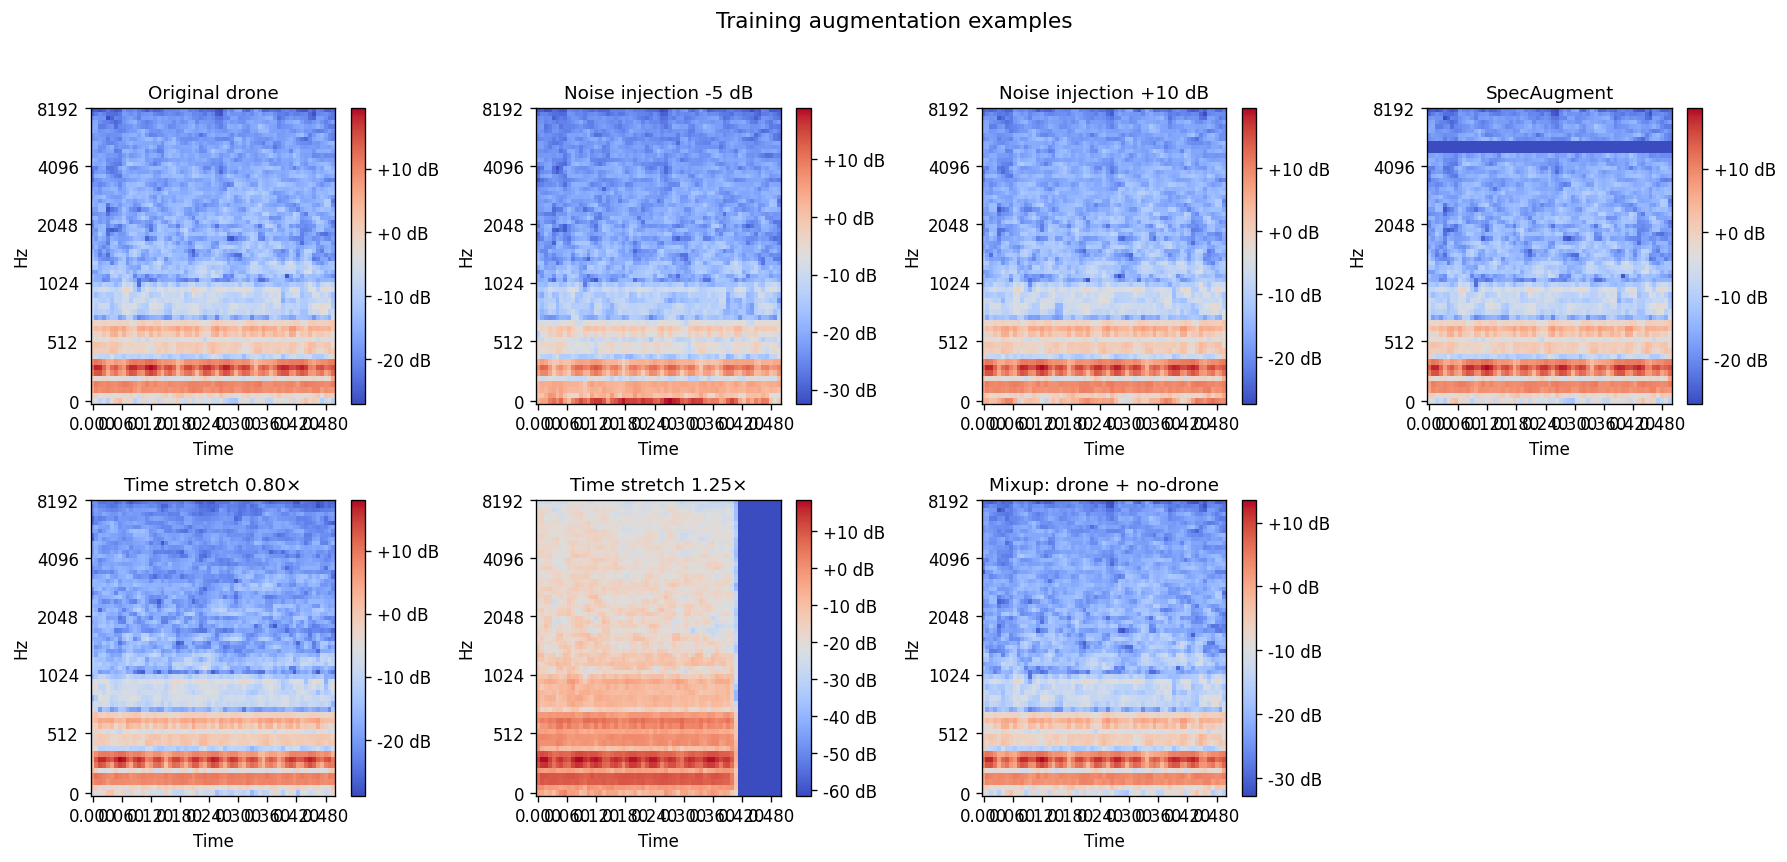

In [7]:
def first_example(X, y, label):
    idx = int(np.where(y == label)[0][0])
    return X[idx]

example_drone = first_example(X_train_wav, y_train_wav, 1)
example_nodrone = first_example(X_train_wav, y_train_wav, 0)

def stft_db(w):
    S = np.abs(librosa.stft(w, n_fft=N_FFT, hop_length=HOP_LENGTH)) ** 2
    return librosa.power_to_db(S, ref=np.max, top_db=TOP_DB)

# Figure: waveform, STFT, mel, log-mel comparisons.
fig, axes = plt.subplots(4, 2, figsize=(12, 11))
time_axis = np.arange(len(example_drone)) / SR_TARGET
for col, (w, label) in enumerate([(example_drone, 'Drone'), (example_nodrone, 'No drone')]):
    axes[0, col].plot(time_axis, w, linewidth=1)
    axes[0, col].set_title(f'{label} waveform')
    axes[0, col].set_xlabel('Time (s)')
    axes[0, col].set_ylabel('Amplitude')
    axes[0, col].grid(alpha=0.25)

    img = librosa.display.specshow(stft_db(w), sr=SR_TARGET, hop_length=HOP_LENGTH, x_axis='time', y_axis='linear', ax=axes[1, col])
    axes[1, col].set_title(f'{label} STFT power spectrogram')
    fig.colorbar(img, ax=axes[1, col], format='%+2.0f dB')

    mel_power = librosa.feature.melspectrogram(y=w, sr=SR_TARGET, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, fmax=FMAX, power=2.0)
    img = librosa.display.specshow(mel_power, sr=SR_TARGET, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', fmax=FMAX, ax=axes[2, col])
    axes[2, col].set_title(f'{label} mel power spectrogram')
    fig.colorbar(img, ax=axes[2, col])

    img = librosa.display.specshow(log_mel_db(w), sr=SR_TARGET, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', fmax=FMAX, ax=axes[3, col])
    axes[3, col].set_title(f'{label} log-mel spectrogram')
    fig.colorbar(img, ax=axes[3, col], format='%+2.0f dB')

fig.suptitle('Representative drone and no-drone audio features', y=1.01, fontsize=13)
save_fig(fig, 'fig_02_feature_extraction_examples')
plt.show()

# Augmentation examples.
def specaugment_np(mel, rl):
    out = mel.copy()
    f = rl.integers(0, FREQ_MASK_MAX + 1)
    if f > 0:
        f0 = rl.integers(0, max(1, N_MELS - f + 1))
        out[f0:f0+f, :] = out.min()
    t = rl.integers(0, TIME_MASK_MAX + 1)
    if t > 0:
        t0 = rl.integers(0, max(1, out.shape[1] - t + 1))
        out[:, t0:t0+t] = out.min()
    return out

aug_rng = np.random.default_rng(SEED)
base_mel = log_mel_db(example_drone)
noise_low = add_real_noise_snr(example_drone, noise_bank, -5, aug_rng)
noise_high = add_real_noise_snr(example_drone, noise_bank, 10, aug_rng)
stretched_slow = librosa.effects.time_stretch(example_drone, rate=0.80)
stretched_fast = librosa.effects.time_stretch(example_drone, rate=1.25)
# crop/pad stretched signals to window length
win_len = len(example_drone)
def crop_pad(x):
    if len(x) >= win_len:
        start = (len(x) - win_len) // 2
        return x[start:start+win_len]
    return np.pad(x, (0, win_len-len(x)))
stretched_slow = crop_pad(stretched_slow)
stretched_fast = crop_pad(stretched_fast)
mixup = 0.5 * example_drone + 0.5 * example_nodrone

aug_items = [
    ('Original drone', base_mel),
    ('Noise injection -5 dB', log_mel_db(noise_low)),
    ('Noise injection +10 dB', log_mel_db(noise_high)),
    ('SpecAugment', specaugment_np(base_mel, aug_rng)),
    ('Time stretch 0.80×', log_mel_db(stretched_slow)),
    ('Time stretch 1.25×', log_mel_db(stretched_fast)),
    ('Mixup: drone + no-drone', log_mel_db(mixup)),
]

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
for ax, (title, mel) in zip(axes.flat, aug_items):
    img = librosa.display.specshow(mel, sr=SR_TARGET, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', fmax=FMAX, ax=ax)
    ax.set_title(title)
    fig.colorbar(img, ax=ax, format='%+2.0f dB')
axes.flat[-1].set_visible(False)
fig.suptitle('Training augmentation examples', y=1.02, fontsize=13)
save_fig(fig, 'fig_03_augmentation_examples')
plt.show()

## 8. Load CNN-Transformer v2 and run/reuse predictions

This cell does **not retrain**. It either loads saved prediction CSVs or uses the saved Keras model to regenerate predictions.

In [11]:
# Prediction cache files.
INT_PRED_CSV = os.path.join(PRED_DIR, 'cnn_transformer_v2_internal_predictions.csv')
EXT_PRED_CSV = os.path.join(PRED_DIR, 'cnn_transformer_v2_external_predictions.csv')
MODEL_META_CSV = os.path.join(TABLE_DIR, 'table_cnn_transformer_v2_model_metadata.csv')

model = load_keras_model(CNN_TF_MODEL_PATH)

# Save model metadata and latency.
model_size_mb = os.path.getsize(CNN_TF_MODEL_PATH) / (1024 * 1024)
dummy = np.random.randn(1, *INPUT_SHAPE).astype(np.float32)
_ = model.predict(dummy, verbose=0)
t0 = time.time()
for _ in range(100):
    _ = model.predict(dummy, verbose=0)
latency_ms = (time.time() - t0) / 100 * 1000
model_meta = pd.DataFrame([{
    'Model': 'CNN-Transformer v2',
    'Parameters': model.count_params(),
    'Model size MB': model_size_mb,
    'Latency ms/window': latency_ms,
    'Window duration s': WIN_S,
    'Real-time factor': latency_ms / (WIN_S * 1000),
    'Speed vs real-time': (WIN_S * 1000) / latency_ms,
}])
display(model_meta)
save_table(model_meta, 'table_cnn_transformer_v2_model_metadata')


def make_eval_batch(wavs, noise=False, rl=None):
    X = []
    for w in wavs:
        ww = np.asarray(w, dtype=np.float32)
        if noise and len(noise_bank) > 0 and rl.random() < AUG_PROB:
            ww = add_real_noise_snr(ww, noise_bank, rl.uniform(SNR_MIN, SNR_MAX), rl)
        X.append(mel_to_model_array(log_mel_db(ww)))
    return np.stack(X).astype(np.float32)


def predict_windows(model, X_wav, noise=False, cache_name='internal'):
    rl = np.random.default_rng(SEED)
    probs = []
    for start in range(0, len(X_wav), BATCH):
        batch_wav = X_wav[start:start+BATCH]
        X = make_eval_batch(batch_wav, noise=noise, rl=rl)
        logits = model.predict(X, batch_size=BATCH, verbose=0).ravel()
        probs.append(tf.sigmoid(logits).numpy())
        if (start // BATCH) % 50 == 0:
            print(f'{cache_name}: {start:,}/{len(X_wav):,}')
    return np.concatenate(probs)

# Internal predictions.
if os.path.exists(INT_PRED_CSV):
    print('Loading cached internal predictions:', INT_PRED_CSV)
    int_pred_df = pd.read_csv(INT_PRED_CSV)
    y_true_internal = int_pred_df['y_true'].values.astype(int)
    y_prob_internal = int_pred_df['y_prob'].values.astype(float)
else:
    print('Computing internal predictions from saved model...')
    y_true_internal = y_test_wav.astype(int)
    y_prob_internal = predict_windows(model, X_test_wav, noise=INTERNAL_NOISY_EVAL, cache_name='internal')
    int_pred_df = pd.DataFrame({'y_true': y_true_internal, 'y_prob': y_prob_internal})
    int_pred_df.to_csv(INT_PRED_CSV, index=False)
    print('Saved:', INT_PRED_CSV)

print('Internal predictions loaded:', len(y_true_internal))
print('Internal ROC AUC:', roc_auc_score(y_true_internal, y_prob_internal))

Loaded model: /content/drive/MyDrive/drone_audio_processed/model_cnntransformer_v2_improved.keras
Parameters: 895,489


,Model,Parameters,Model size MB,Latency ms/window,Window duration s,Real-time factor,Speed vs real-time
0,CNN-Transformer v2,895489,17.469172,101.105196,0.5,0.20221,4.945344


Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/tables/table_cnn_transformer_v2_model_metadata.csv
Computing internal predictions from saved model...
internal: 0/32,694
internal: 3,200/32,694
internal: 6,400/32,694
internal: 9,600/32,694
internal: 12,800/32,694
internal: 16,000/32,694
internal: 19,200/32,694
internal: 22,400/32,694
internal: 25,600/32,694
internal: 28,800/32,694
internal: 32,000/32,694
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/predictions/cnn_transformer_v2_internal_predictions.csv
Internal predictions loaded: 32694
Internal ROC AUC: 0.9963455449543797


## 9. External Svanström dataset evaluation

This downloads/reuses the external WAV dataset, evaluates the CNN-Transformer v2 at clip level, and caches standard and TTA probabilities.

In [12]:
def ensure_external_dataset():
    os.makedirs(EXT_ROOT, exist_ok=True)
    zip_path = os.path.join(EXT_ROOT, 'repo.zip')
    extract_dir = os.path.join(EXT_ROOT, 'repo')
    wavs = glob.glob(os.path.join(extract_dir, '**', '*.wav'), recursive=True)
    if wavs:
        return sorted(wavs)
    if not os.path.exists(zip_path):
        print('Downloading external Svanström dataset...')
        r = requests.get(EXT_ZIP_URL, stream=True, timeout=120)
        r.raise_for_status()
        with open(zip_path, 'wb') as f:
            for chunk in r.iter_content(1024 * 1024):
                if chunk:
                    f.write(chunk)
    print('Extracting external dataset...')
    with zipfile.ZipFile(zip_path) as z:
        z.extractall(extract_dir)
    wavs = sorted(glob.glob(os.path.join(extract_dir, '**', '*.wav'), recursive=True))
    if not wavs:
        raise RuntimeError('No WAV files found in external dataset after extraction.')
    return wavs


def predict_external_clip(model, wav_path, rl, standard_uses_noise=True, tta_n=TTA_N_AUGMENTS):
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    if sr != SR_TARGET:
        y = librosa.resample(y, orig_sr=sr, target_sr=SR_TARGET)
    wins = windows_all(y, SR_TARGET, WIN_S, HOP_S)
    if not wins:
        return 0.0, 0.0

    # Standard clip probability = max window probability.
    X_std = []
    for w in wins:
        ww = w
        if standard_uses_noise and len(noise_bank) > 0 and rl.random() < AUG_PROB:
            ww = add_real_noise_snr(ww, noise_bank, rl.uniform(SNR_MIN, SNR_MAX), rl)
        X_std.append(mel_to_model_array(log_mel_db(ww)))
    logits_std = model.predict(np.stack(X_std), batch_size=BATCH, verbose=0).ravel()
    prob_std = float(np.max(tf.sigmoid(logits_std).numpy()))

    # TTA probability = max window probability after averaging logits across noisy passes.
    all_logits = []
    for _ in range(tta_n):
        X_tta = []
        for w in wins:
            ww = w
            if len(noise_bank) > 0:
                ww = add_real_noise_snr(ww, noise_bank, rl.uniform(SNR_MIN, SNR_MAX), rl)
            X_tta.append(mel_to_model_array(log_mel_db(ww)))
        all_logits.append(model.predict(np.stack(X_tta), batch_size=BATCH, verbose=0).ravel())
    prob_tta = float(np.max(tf.sigmoid(np.mean(all_logits, axis=0)).numpy()))
    return prob_std, prob_tta

if os.path.exists(EXT_PRED_CSV):
    print('Loading cached external predictions:', EXT_PRED_CSV)
    ext_pred_df = pd.read_csv(EXT_PRED_CSV)
else:
    ext_wavs = ensure_external_dataset()
    ext_rng = np.random.default_rng(SEED)
    rows = []
    print(f'Evaluating {len(ext_wavs)} external clips...')
    for i, p in enumerate(ext_wavs):
        label = 1 if 'drone' in os.path.basename(p).lower() else 0
        prob_std, prob_tta = predict_external_clip(model, p, ext_rng, EXTERNAL_STANDARD_USES_NOISE, TTA_N_AUGMENTS)
        rows.append({
            'file': p,
            'filename': os.path.basename(p),
            'y_true': label,
            'prob_standard': prob_std,
            'prob_tta': prob_tta,
        })
        if i % 10 == 0:
            print(f'  {i}/{len(ext_wavs)}')
    ext_pred_df = pd.DataFrame(rows)
    ext_pred_df.to_csv(EXT_PRED_CSV, index=False)
    print('Saved:', EXT_PRED_CSV)

y_true_external = ext_pred_df['y_true'].values.astype(int)
y_prob_external_std = ext_pred_df['prob_standard'].values.astype(float)
y_prob_external_tta = ext_pred_df['prob_tta'].values.astype(float)

print('External clips:', len(y_true_external))
print('Drone clips:', int(y_true_external.sum()))
print('No-drone clips:', int((y_true_external == 0).sum()))
print('External AUC standard:', roc_auc_score(y_true_external, y_prob_external_std))
print('External AUC TTA:', roc_auc_score(y_true_external, y_prob_external_tta))

Extracting external dataset...
Evaluating 90 external clips...
  0/90
  10/90
  20/90
  30/90
  40/90
  50/90
  60/90
  70/90
  80/90
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/predictions/cnn_transformer_v2_external_predictions.csv
External clips: 90
Drone clips: 30
No-drone clips: 60
External AUC standard: 0.4444444444444445
External AUC TTA: 0.4633333333333333


## 10. Internal and external metric tables

This exports CSV/XLSX tables for the thesis Results chapter.

In [13]:
# Thresholds of interest.
STD_THRESHOLD = 0.50
LOW_THRESHOLD = 0.05

metrics_rows = []
metrics_rows.append(make_metrics_row('CNN-Transformer v2', y_true_internal, y_prob_internal, STD_THRESHOLD, 'Internal noisy test'))
metrics_rows.append(make_metrics_row('CNN-Transformer v2', y_true_internal, y_prob_internal, LOW_THRESHOLD, 'Internal noisy test'))
metrics_rows.append(make_metrics_row('CNN-Transformer v2 standard', y_true_external, y_prob_external_std, STD_THRESHOLD, 'External Svanström'))
metrics_rows.append(make_metrics_row('CNN-Transformer v2 standard', y_true_external, y_prob_external_std, LOW_THRESHOLD, 'External Svanström'))
metrics_rows.append(make_metrics_row('CNN-Transformer v2 TTA', y_true_external, y_prob_external_tta, STD_THRESHOLD, 'External Svanström'))
metrics_rows.append(make_metrics_row('CNN-Transformer v2 TTA', y_true_external, y_prob_external_tta, LOW_THRESHOLD, 'External Svanström'))

metrics_df = pd.DataFrame(metrics_rows)
display(metrics_df)
save_table(metrics_df, 'table_cnn_transformer_v2_metrics')

# Human-readable percentage version.
metrics_pretty = metrics_df.copy()
for col in ['Accuracy', 'ROC AUC', 'Average Precision', 'Drone Precision', 'Drone Recall', 'Drone F1']:
    metrics_pretty[col] = metrics_pretty[col].map(lambda x: f'{x:.4f}')
display(metrics_pretty)
save_table(metrics_pretty, 'table_cnn_transformer_v2_metrics_pretty')

,Model,Dataset,Threshold,Accuracy,ROC AUC,Average Precision,Drone Precision,Drone Recall,Drone F1,TN,FP,FN,TP
0,CNN-Transformer v2,Internal noisy test,0.50,0.987796,0.996346,0.997571,0.992765,0.983532,0.988127,15692,121,278,16603
1,CNN-Transformer v2,Internal noisy test,0.05,0.981281,0.996346,0.997571,0.976510,0.987501,0.981975,15412,401,211,16670
2,CNN-Transformer v2 standard,External Svanström,0.50,0.411111,0.444444,0.295152,0.333333,0.766667,0.464646,14,46,7,23
3,CNN-Transformer v2 standard,External Svanström,0.05,0.400000,0.444444,0.295152,0.357143,1.000000,0.526316,6,54,0,30
4,CNN-Transformer v2 TTA,External Svanström,0.50,0.422222,0.463333,0.315132,0.303571,0.566667,0.395349,21,39,13,17
5,CNN-Transformer v2 TTA,External Svanström,0.05,0.411111,0.463333,0.315132,0.354430,0.933333,0.513761,9,51,2,28


Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/tables/table_cnn_transformer_v2_metrics.csv


,Model,Dataset,Threshold,Accuracy,ROC AUC,Average Precision,Drone Precision,Drone Recall,Drone F1,TN,FP,FN,TP
0,CNN-Transformer v2,Internal noisy test,0.50,0.9878,0.9963,0.9976,0.9928,0.9835,0.9881,15692,121,278,16603
1,CNN-Transformer v2,Internal noisy test,0.05,0.9813,0.9963,0.9976,0.9765,0.9875,0.9820,15412,401,211,16670
2,CNN-Transformer v2 standard,External Svanström,0.50,0.4111,0.4444,0.2952,0.3333,0.7667,0.4646,14,46,7,23
3,CNN-Transformer v2 standard,External Svanström,0.05,0.4000,0.4444,0.2952,0.3571,1.0000,0.5263,6,54,0,30
4,CNN-Transformer v2 TTA,External Svanström,0.50,0.4222,0.4633,0.3151,0.3036,0.5667,0.3953,21,39,13,17
5,CNN-Transformer v2 TTA,External Svanström,0.05,0.4111,0.4633,0.3151,0.3544,0.9333,0.5138,9,51,2,28


Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/tables/table_cnn_transformer_v2_metrics_pretty.csv


'/content/drive/MyDrive/drone_audio_processed/thesis_results/tables/table_cnn_transformer_v2_metrics_pretty.csv'

## 11. Confusion matrices

Exports thesis-ready internal and external confusion matrices.

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_04_internal_confusion_matrices.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_04_internal_confusion_matrices.pdf


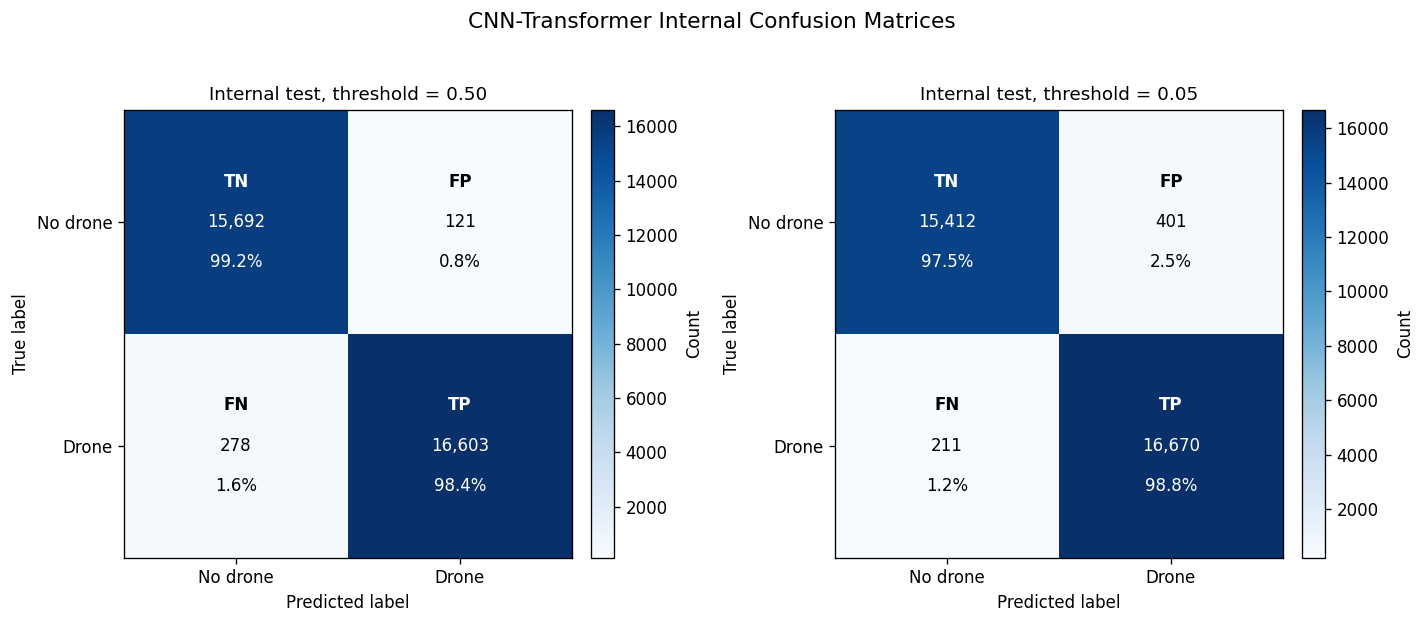

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_05_external_confusion_matrices.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_05_external_confusion_matrices.pdf


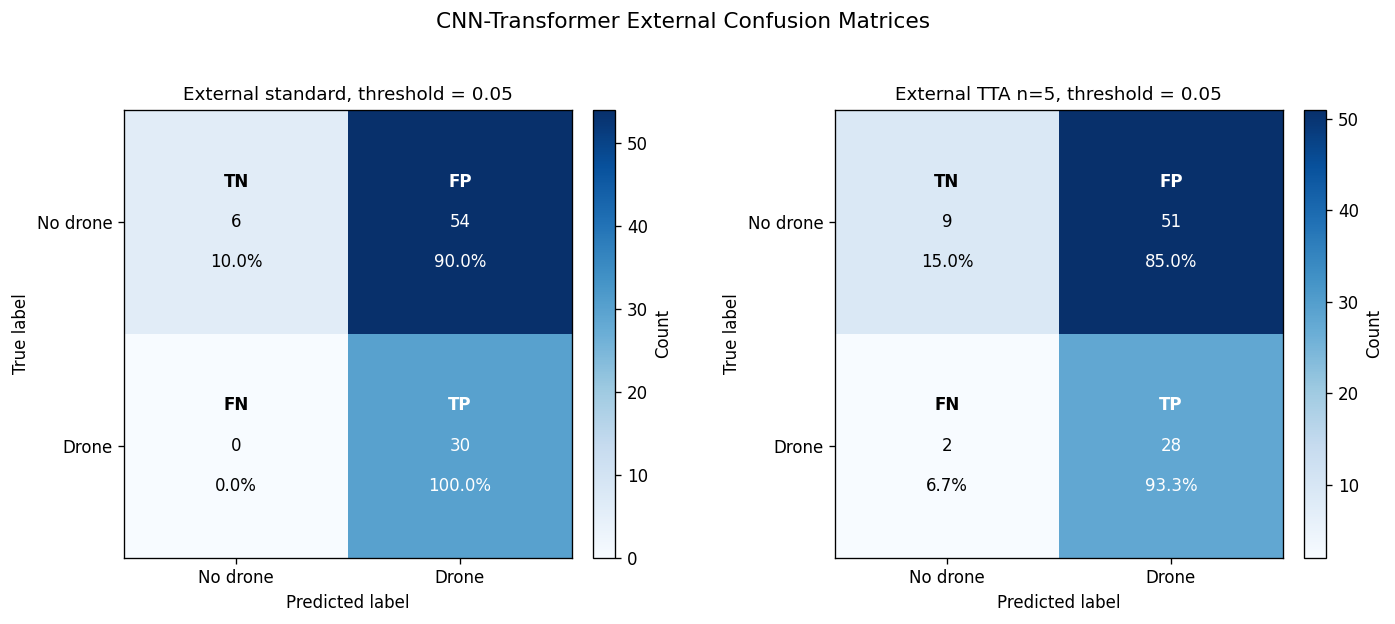

In [28]:
# Internal confusion matrices.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_int_05 = confusion_matrix(y_true_internal, (y_prob_internal >= 0.50).astype(int), labels=[0, 1])
cm_int_005 = confusion_matrix(y_true_internal, (y_prob_internal >= 0.05).astype(int), labels=[0, 1])
plot_cm(cm_int_05, 'Internal test, threshold = 0.50', axes[0])
plot_cm(cm_int_005, 'Internal test, threshold = 0.05', axes[1])
fig.suptitle('CNN-Transformer Internal Confusion Matrices', y=1.03, fontsize=13)
save_fig(fig, 'fig_04_internal_confusion_matrices')
plt.show()

# External confusion matrices: standard and TTA at low threshold.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_ext_std = confusion_matrix(y_true_external, (y_prob_external_std >= 0.05).astype(int), labels=[0, 1])
cm_ext_tta = confusion_matrix(y_true_external, (y_prob_external_tta >= 0.05).astype(int), labels=[0, 1])
plot_cm(cm_ext_std, 'External standard, threshold = 0.05', axes[0])
plot_cm(cm_ext_tta, f'External TTA n={TTA_N_AUGMENTS}, threshold = 0.05', axes[1])
fig.suptitle('CNN-Transformer External Confusion Matrices', y=1.03, fontsize=13)
save_fig(fig, 'fig_05_external_confusion_matrices')
plt.show()

## 12. ROC and precision-recall curves

These figures show threshold-independent ranking performance. Use them to support the discussion that external domain shift remains a limitation.

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_06_roc_curves.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_06_roc_curves.pdf


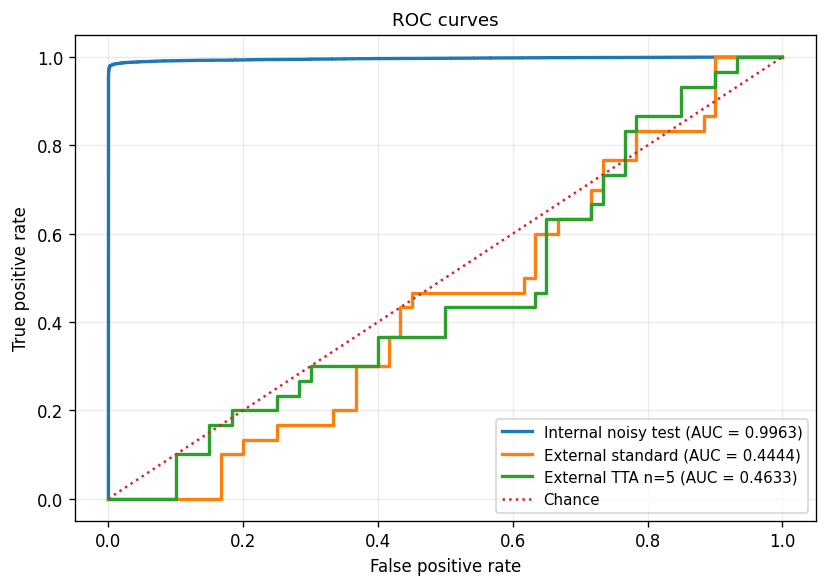

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_07_precision_recall_curves.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_07_precision_recall_curves.pdf


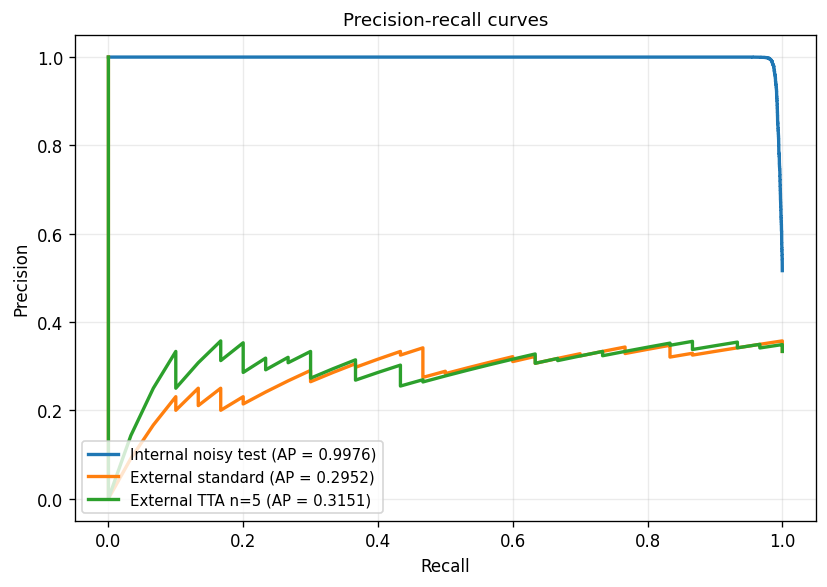

In [15]:
# ROC curves.
fig, ax = plt.subplots(figsize=(7, 5))
for label, yt, yp in [
    ('Internal noisy test', y_true_internal, y_prob_internal),
    ('External standard', y_true_external, y_prob_external_std),
    (f'External TTA n={TTA_N_AUGMENTS}', y_true_external, y_prob_external_tta),
]:
    fpr, tpr, _ = roc_curve(yt, yp)
    auc = roc_auc_score(yt, yp)
    ax.plot(fpr, tpr, linewidth=2, label=f'{label} (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], linestyle=':', label='Chance')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curves')
ax.grid(alpha=0.25)
ax.legend(loc='lower right')
save_fig(fig, 'fig_06_roc_curves')
plt.show()

# Precision-recall curves.
fig, ax = plt.subplots(figsize=(7, 5))
for label, yt, yp in [
    ('Internal noisy test', y_true_internal, y_prob_internal),
    ('External standard', y_true_external, y_prob_external_std),
    (f'External TTA n={TTA_N_AUGMENTS}', y_true_external, y_prob_external_tta),
]:
    precision, recall, _ = precision_recall_curve(yt, yp)
    ap = average_precision_score(yt, yp)
    ax.plot(recall, precision, linewidth=2, label=f'{label} (AP = {ap:.4f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-recall curves')
ax.grid(alpha=0.25)
ax.legend(loc='lower left')
save_fig(fig, 'fig_07_precision_recall_curves')
plt.show()

## 13. Threshold sweeps

This reproduces the threshold-optimisation analysis and exports the tables used for the Results section.

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/tables/table_threshold_sweep_cnn_transformer_v2_standard.csv
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/tables/table_threshold_sweep_cnn_transformer_v2_tta.csv


,Model,Threshold,Internal Drone F1,External Drone Recall,External Drone F1,Combined Score,Internal FP,Internal FN,External FP,External FN
0,CNN-Transformer v2 standard,0.05,0.981975,1.000000,0.526316,0.990905,401,211,54,0
1,CNN-Transformer v2 standard,0.10,0.983872,0.866667,0.472727,0.921558,319,227,54,4
2,CNN-Transformer v2 standard,0.15,0.984822,0.866667,0.477064,0.921974,275,238,53,4
3,CNN-Transformer v2 standard,0.20,0.985574,0.833333,0.467290,0.903083,242,245,52,5
4,CNN-Transformer v2 standard,0.25,0.986331,0.833333,0.471698,0.903400,213,248,51,5
5,CNN-Transformer v2 standard,0.30,0.986797,0.833333,0.476190,0.903596,194,251,50,5
6,CNN-Transformer v2 standard,0.35,0.987438,0.833333,0.485437,0.903864,167,256,48,5
7,CNN-Transformer v2 standard,0.40,0.987784,0.833333,0.490196,0.904009,147,264,47,5
8,CNN-Transformer v2 standard,0.45,0.988073,0.833333,0.490196,0.904130,130,271,47,5
9,CNN-Transformer v2 standard,0.50,0.988127,0.766667,0.464646,0.863422,121,278,46,7


,Model,Threshold,Internal Drone F1,External Drone Recall,External Drone F1,Combined Score,Internal FP,Internal FN,External FP,External FN
0,CNN-Transformer v2 TTA n=5,0.05,0.981975,0.933333,0.513761,0.957036,401,211,51,2
1,CNN-Transformer v2 TTA n=5,0.10,0.983872,0.866667,0.504854,0.921558,319,227,47,4
2,CNN-Transformer v2 TTA n=5,0.15,0.984822,0.766667,0.464646,0.862158,275,238,46,7
3,CNN-Transformer v2 TTA n=5,0.20,0.985574,0.733333,0.458333,0.840946,242,245,44,8
4,CNN-Transformer v2 TTA n=5,0.25,0.986331,0.666667,0.425532,0.795590,213,248,44,10
5,CNN-Transformer v2 TTA n=5,0.30,0.986797,0.633333,0.422222,0.771508,194,251,41,11
6,CNN-Transformer v2 TTA n=5,0.35,0.987438,0.633333,0.431818,0.771703,167,256,39,11
7,CNN-Transformer v2 TTA n=5,0.40,0.987784,0.566667,0.395349,0.720183,147,264,39,13
8,CNN-Transformer v2 TTA n=5,0.45,0.988073,0.566667,0.395349,0.720260,130,271,39,13
9,CNN-Transformer v2 TTA n=5,0.50,0.988127,0.566667,0.395349,0.720274,121,278,39,13


Best standard threshold by combined score:


,Model,Threshold,Internal Drone F1,External Drone Recall,External Drone F1,Combined Score,Internal FP,Internal FN,External FP,External FN
0,CNN-Transformer v2 standard,0.05,0.981975,1.0,0.526316,0.990905,401,211,54,0


Best TTA threshold by combined score:


,Model,Threshold,Internal Drone F1,External Drone Recall,External Drone F1,Combined Score,Internal FP,Internal FN,External FP,External FN
0,CNN-Transformer v2 TTA n=5,0.05,0.981975,0.933333,0.513761,0.957036,401,211,51,2


Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_08_threshold_sweep_standard.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_08_threshold_sweep_standard.pdf


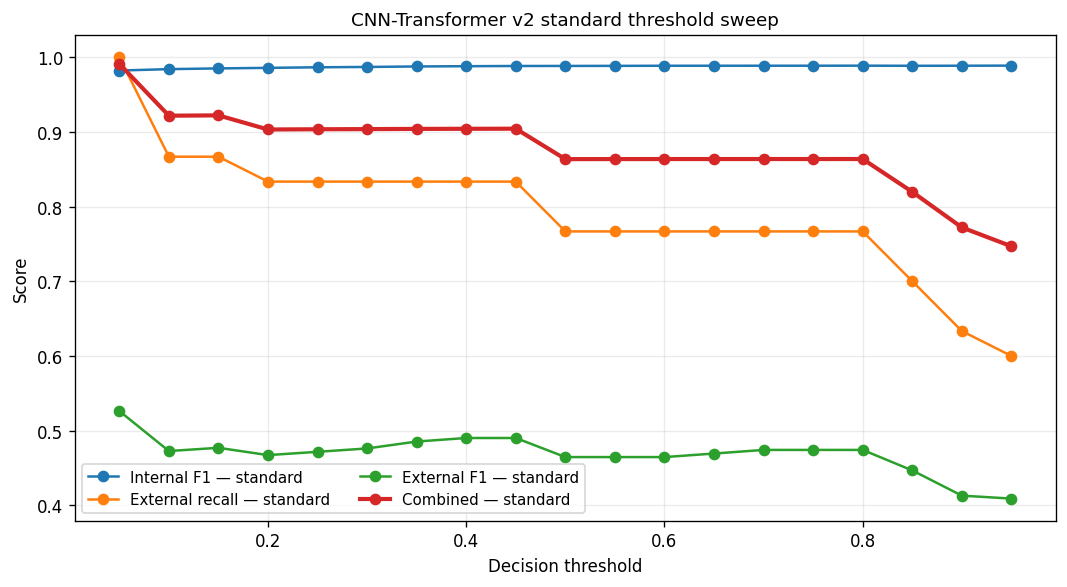

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_09_threshold_sweep_tta.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_09_threshold_sweep_tta.pdf


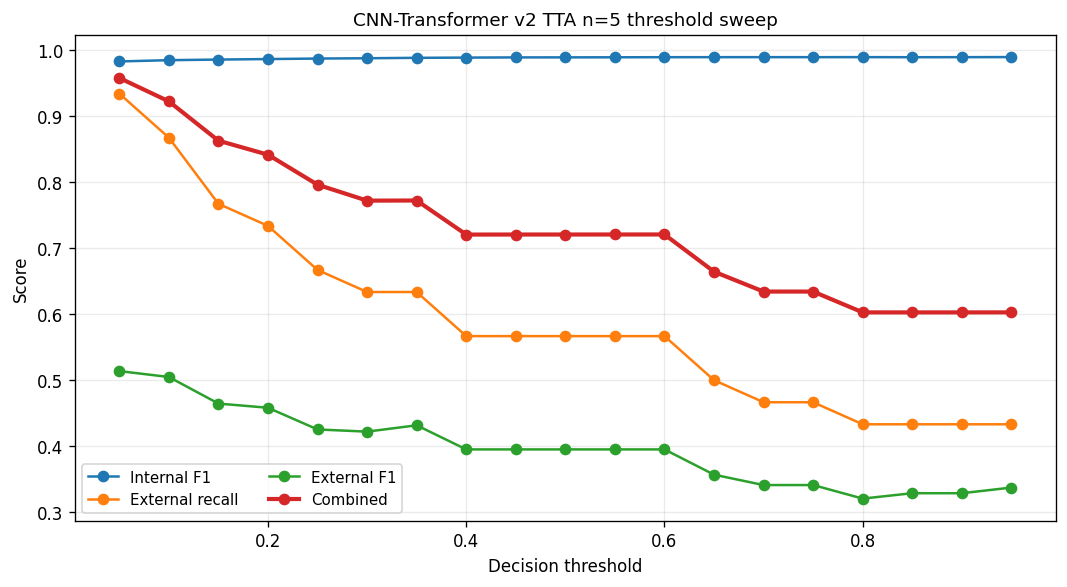

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_10_threshold_sweep_standard_vs_tta.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_10_threshold_sweep_standard_vs_tta.pdf


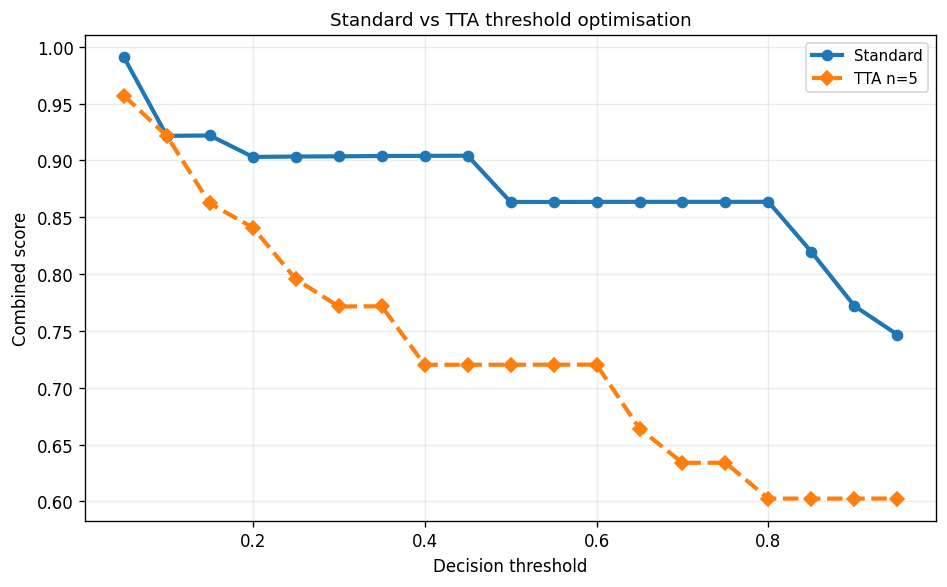

In [16]:
df_sweep_std = threshold_sweep(
    y_true_internal, y_prob_internal,
    y_true_external, y_prob_external_std,
    model_name='CNN-Transformer v2 standard'
)
df_sweep_tta = threshold_sweep(
    y_true_internal, y_prob_internal,
    y_true_external, y_prob_external_tta,
    model_name=f'CNN-Transformer v2 TTA n={TTA_N_AUGMENTS}'
)

save_table(df_sweep_std, 'table_threshold_sweep_cnn_transformer_v2_standard')
save_table(df_sweep_tta, 'table_threshold_sweep_cnn_transformer_v2_tta')

display(df_sweep_std)
display(df_sweep_tta)

best_std = df_sweep_std.loc[df_sweep_std['Combined Score'].idxmax()]
best_tta = df_sweep_tta.loc[df_sweep_tta['Combined Score'].idxmax()]
print('Best standard threshold by combined score:')
display(best_std.to_frame().T)
print('Best TTA threshold by combined score:')
display(best_tta.to_frame().T)

# Threshold sweep plot.
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_sweep_std['Threshold'], df_sweep_std['Internal Drone F1'], marker='o', label='Internal F1 — standard')
ax.plot(df_sweep_std['Threshold'], df_sweep_std['External Drone Recall'], marker='o', label='External recall — standard')
ax.plot(df_sweep_std['Threshold'], df_sweep_std['External Drone F1'], marker='o', label='External F1 — standard')
ax.plot(df_sweep_std['Threshold'], df_sweep_std['Combined Score'], marker='o', linewidth=2.5, label='Combined — standard')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('CNN-Transformer v2 standard threshold sweep')
ax.grid(alpha=0.25)
ax.legend(ncol=2)
save_fig(fig, 'fig_08_threshold_sweep_standard')
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_sweep_tta['Threshold'], df_sweep_tta['Internal Drone F1'], marker='o', label='Internal F1')
ax.plot(df_sweep_tta['Threshold'], df_sweep_tta['External Drone Recall'], marker='o', label='External recall')
ax.plot(df_sweep_tta['Threshold'], df_sweep_tta['External Drone F1'], marker='o', label='External F1')
ax.plot(df_sweep_tta['Threshold'], df_sweep_tta['Combined Score'], marker='o', linewidth=2.5, label='Combined')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title(f'CNN-Transformer v2 TTA n={TTA_N_AUGMENTS} threshold sweep')
ax.grid(alpha=0.25)
ax.legend(ncol=2)
save_fig(fig, 'fig_09_threshold_sweep_tta')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_sweep_std['Threshold'], df_sweep_std['Combined Score'], marker='o', linewidth=2.5, label='Standard')
ax.plot(df_sweep_tta['Threshold'], df_sweep_tta['Combined Score'], marker='D', linewidth=2.5, linestyle='--', label=f'TTA n={TTA_N_AUGMENTS}')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Combined score')
ax.set_title('Standard vs TTA threshold optimisation')
ax.grid(alpha=0.25)
ax.legend()
save_fig(fig, 'fig_10_threshold_sweep_standard_vs_tta')
plt.show()

## 14. External probability distributions

This figure helps explain why a low threshold improves external recall, while AUC remains weak.

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_11_external_probability_distributions.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_11_external_probability_distributions.pdf


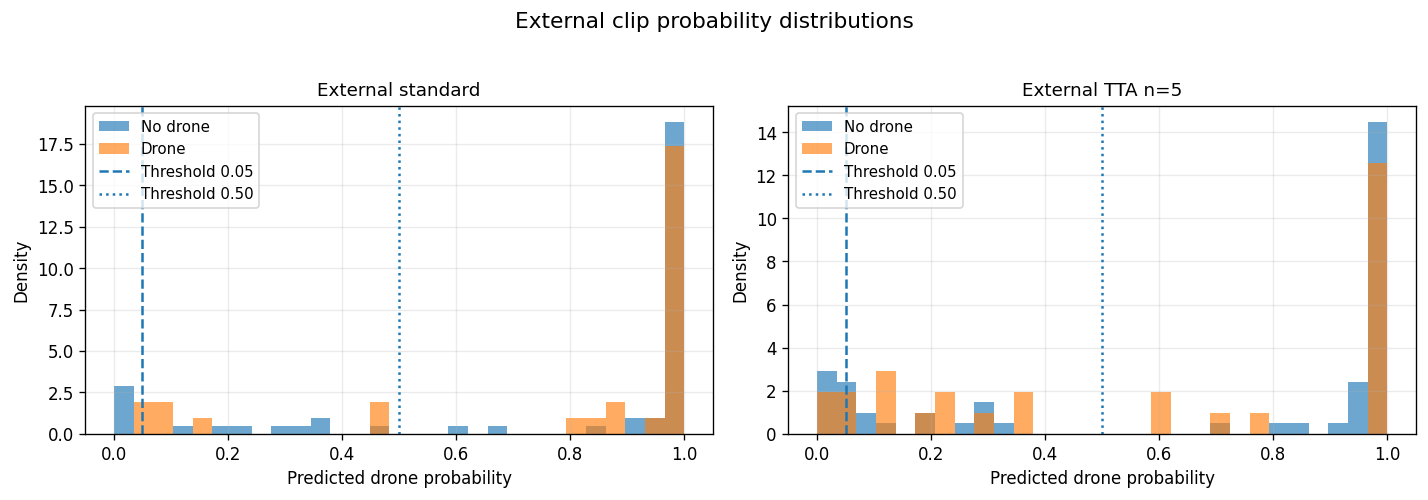

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(0, 1, 30)
mask_drone = y_true_external == 1
mask_nodrone = y_true_external == 0

for ax, probs, title in [
    (axes[0], y_prob_external_std, 'External standard'),
    (axes[1], y_prob_external_tta, f'External TTA n={TTA_N_AUGMENTS}'),
]:
    ax.hist(probs[mask_nodrone], bins=bins, alpha=0.65, label='No drone', density=True)
    ax.hist(probs[mask_drone], bins=bins, alpha=0.65, label='Drone', density=True)
    ax.axvline(0.05, linestyle='--', linewidth=1.5, label='Threshold 0.05')
    ax.axvline(0.50, linestyle=':', linewidth=1.5, label='Threshold 0.50')
    ax.set_xlabel('Predicted drone probability')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()
fig.suptitle('External clip probability distributions', y=1.03, fontsize=13)
save_fig(fig, 'fig_11_external_probability_distributions')
plt.show()

## 15. LWCNN vs CNN-Transformer comparison table and plots

The LWCNN values below are editable. Replace them with your final selected LWCNN run if needed. This avoids accidentally mixing old and new LWCNN runs.

,Model,Internal Accuracy,Internal ROC AUC,Internal Drone Precision,Internal Drone Recall,Internal Drone F1,External ROC AUC,Best External Recall,Best External Drone F1,Best Threshold,Parameters,Latency ms/window
0,LWCNN,0.981000,0.995600,0.984800,0.978200,0.981500,0.641000,0.3333,0.335600,0.30,219137,32.530000
1,CNN-Transformer v2,0.987796,0.996346,0.992765,0.983532,0.988127,0.444444,1.0000,0.526316,0.05,895489,101.105196


Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/tables/table_lwcnn_vs_cnn_transformer_v2_comparison.csv
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_12_lwcnn_vs_cnn_transformer_performance.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_12_lwcnn_vs_cnn_transformer_performance.pdf


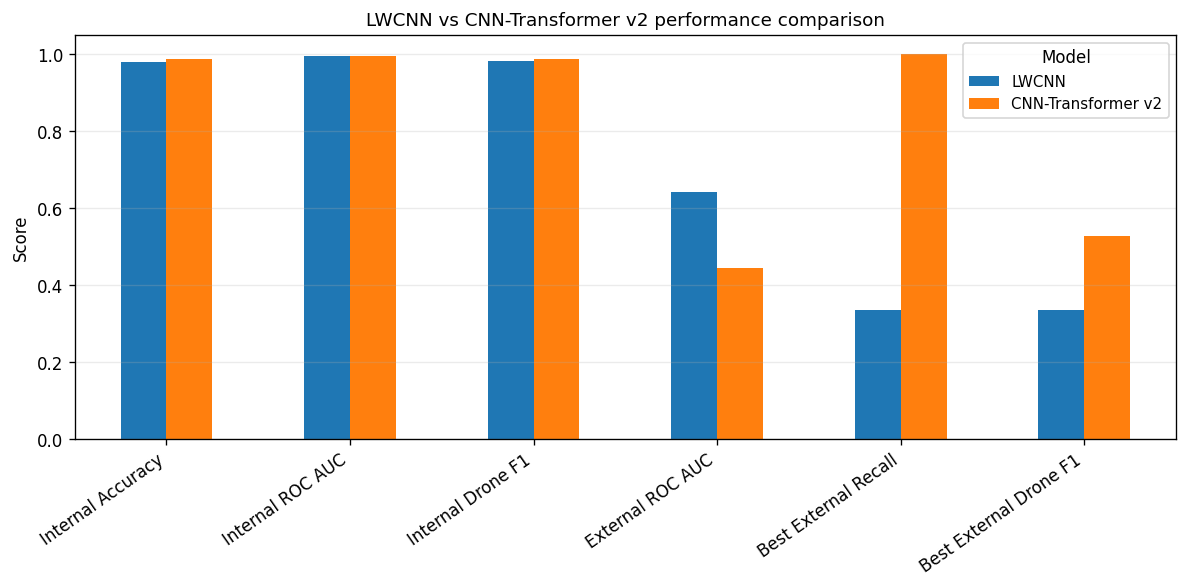

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_13_model_complexity_latency_tradeoff.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_13_model_complexity_latency_tradeoff.pdf


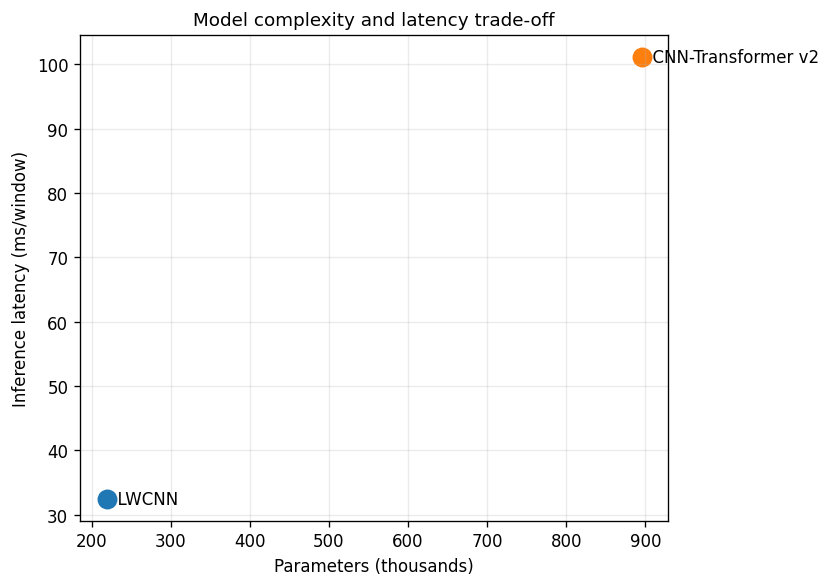

Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_14_external_recall_latency_tradeoff.png
Saved: /content/drive/MyDrive/drone_audio_processed/thesis_results/figures/fig_14_external_recall_latency_tradeoff.pdf


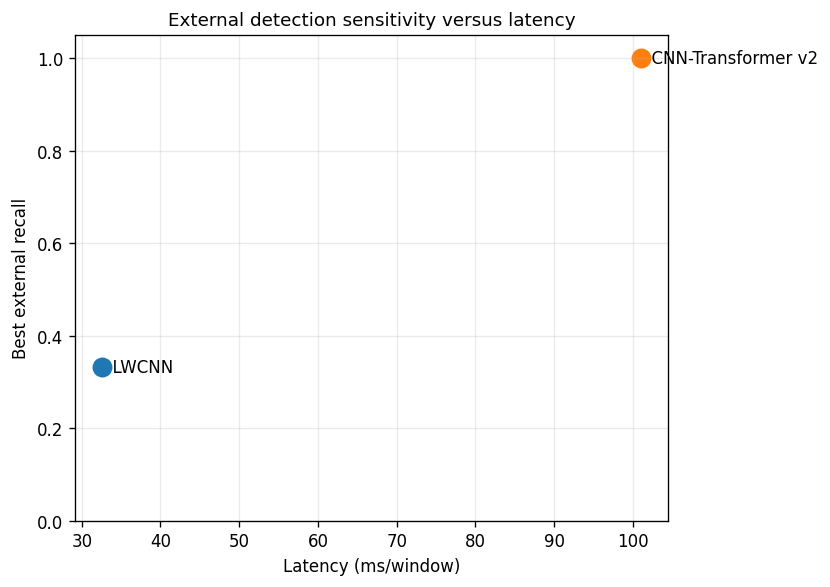

In [18]:
# ---------------------------------------------------------------------
# IMPORTANT: edit these LWCNN values if your final thesis baseline differs.
# These defaults reflect the LWCNN comparison values currently used in your report/table.
# ---------------------------------------------------------------------
lwcnn_manual = {
    'Model': 'LWCNN',
    'Internal Accuracy': 0.9810,
    'Internal ROC AUC': 0.9956,
    'Internal Drone Precision': 0.9848,
    'Internal Drone Recall': 0.9782,
    'Internal Drone F1': 0.9815,
    'External ROC AUC': 0.6410,        # update if using another final LWCNN run
    'Best External Recall': 0.3333,    # from threshold sweep t=0.30 in current report
    'Best External Drone F1': 0.3356,
    'Best Threshold': 0.30,
    'Parameters': 219137,
    'Latency ms/window': 32.53,
}

# CNN-Transformer v2 values from the actual regenerated/cached evaluation.
ct_best = df_sweep_std.loc[df_sweep_std['Combined Score'].idxmax()]
ct_best_f1 = df_sweep_std.loc[df_sweep_std['External Drone F1'].idxmax()]
ct_row = {
    'Model': 'CNN-Transformer v2',
    'Internal Accuracy': make_metrics_row('tmp', y_true_internal, y_prob_internal, 0.50)['Accuracy'],
    'Internal ROC AUC': roc_auc_score(y_true_internal, y_prob_internal),
    'Internal Drone Precision': make_metrics_row('tmp', y_true_internal, y_prob_internal, 0.50)['Drone Precision'],
    'Internal Drone Recall': make_metrics_row('tmp', y_true_internal, y_prob_internal, 0.50)['Drone Recall'],
    'Internal Drone F1': make_metrics_row('tmp', y_true_internal, y_prob_internal, 0.50)['Drone F1'],
    'External ROC AUC': roc_auc_score(y_true_external, y_prob_external_std),
    'Best External Recall': ct_best['External Drone Recall'],
    'Best External Drone F1': ct_best_f1['External Drone F1'],
    'Best Threshold': ct_best['Threshold'],
    'Parameters': int(model_meta.loc[0, 'Parameters']),
    'Latency ms/window': float(model_meta.loc[0, 'Latency ms/window']),
}

comparison_df = pd.DataFrame([lwcnn_manual, ct_row])
display(comparison_df)
save_table(comparison_df, 'table_lwcnn_vs_cnn_transformer_v2_comparison')

# Bar plot: key performance metrics.
metrics_to_plot = [
    'Internal Accuracy', 'Internal ROC AUC', 'Internal Drone F1',
    'External ROC AUC', 'Best External Recall', 'Best External Drone F1'
]
plot_df = comparison_df.set_index('Model')[metrics_to_plot].T
fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind='bar', ax=ax)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('LWCNN vs CNN-Transformer v2 performance comparison')
ax.grid(axis='y', alpha=0.25)
ax.legend(title='Model')
plt.xticks(rotation=35, ha='right')
save_fig(fig, 'fig_12_lwcnn_vs_cnn_transformer_performance')
plt.show()

# Complexity/deployment trade-off.
fig, ax = plt.subplots(figsize=(7, 5))
for _, row in comparison_df.iterrows():
    ax.scatter(row['Parameters'] / 1000, row['Latency ms/window'], s=120, label=row['Model'])
    ax.text(row['Parameters'] / 1000, row['Latency ms/window'], '  ' + row['Model'], va='center')
ax.set_xlabel('Parameters (thousands)')
ax.set_ylabel('Inference latency (ms/window)')
ax.set_title('Model complexity and latency trade-off')
ax.grid(alpha=0.25)
save_fig(fig, 'fig_13_model_complexity_latency_tradeoff')
plt.show()

# Accuracy/F1 versus latency trade-off.
fig, ax = plt.subplots(figsize=(7, 5))
for _, row in comparison_df.iterrows():
    ax.scatter(row['Latency ms/window'], row['Best External Recall'], s=120, label=row['Model'])
    ax.text(row['Latency ms/window'], row['Best External Recall'], '  ' + row['Model'], va='center')
ax.set_xlabel('Latency (ms/window)')
ax.set_ylabel('Best external recall')
ax.set_ylim(0, 1.05)
ax.set_title('External detection sensitivity versus latency')
ax.grid(alpha=0.25)
save_fig(fig, 'fig_14_external_recall_latency_tradeoff')
plt.show()

## 16. Optional: evaluate a saved LWCNN model

This section is optional. If you have a saved `.keras` LWCNN model, set `LWCNN_MODEL_PATH` in the configuration cell and run this section. If not, skip it and use the manual comparison table above.

In [19]:
if LWCNN_MODEL_PATH is None or not os.path.exists(str(LWCNN_MODEL_PATH)):
    print('Skipping optional LWCNN model evaluation. Set LWCNN_MODEL_PATH to a valid .keras file to enable it.')
else:
    lwcnn_model = load_keras_model(LWCNN_MODEL_PATH)
    lwcnn_int_csv = os.path.join(PRED_DIR, 'lwcnn_internal_predictions.csv')
    if os.path.exists(lwcnn_int_csv):
        lwcnn_int_df = pd.read_csv(lwcnn_int_csv)
        y_prob_lwcnn_internal = lwcnn_int_df['y_prob'].values.astype(float)
    else:
        y_prob_lwcnn_internal = predict_windows(lwcnn_model, X_test_wav, noise=INTERNAL_NOISY_EVAL, cache_name='lwcnn_internal')
        pd.DataFrame({'y_true': y_test_wav.astype(int), 'y_prob': y_prob_lwcnn_internal}).to_csv(lwcnn_int_csv, index=False)
    print('LWCNN internal AUC:', roc_auc_score(y_test_wav.astype(int), y_prob_lwcnn_internal))

Skipping optional LWCNN model evaluation. Set LWCNN_MODEL_PATH to a valid .keras file to enable it.


## 17. Results summary text for thesis drafting

This cell creates a short Markdown summary using the values generated above. You can paste/adapt it into the Results and Discussion chapter.

In [20]:
# Build a compact narrative summary from generated results.
int_05 = make_metrics_row('CNN-Transformer v2', y_true_internal, y_prob_internal, 0.50, 'Internal noisy test')
ext_05 = make_metrics_row('CNN-Transformer v2 standard', y_true_external, y_prob_external_std, 0.50, 'External Svanström')
ext_low = make_metrics_row('CNN-Transformer v2 standard', y_true_external, y_prob_external_std, float(ct_best['Threshold']), 'External Svanström')

summary_text = f"""
# CNN-Transformer v2 Results Summary

The CNN-Transformer v2 contained **{int(model_meta.loc[0, 'Parameters']):,} parameters** and achieved a mean single-window inference latency of **{float(model_meta.loc[0, 'Latency ms/window']):.2f} ms** for a {WIN_S:.1f} s audio window. This corresponds to a real-time factor of **{float(model_meta.loc[0, 'Real-time factor']):.3f}×**, or approximately **{float(model_meta.loc[0, 'Speed vs real-time']):.1f}× faster than real time**.

On the internal noisy DADS test set at threshold 0.50, the model achieved **{int_05['Accuracy']:.4f} accuracy**, **{int_05['ROC AUC']:.4f} ROC-AUC**, **{int_05['Drone Precision']:.4f} drone precision**, **{int_05['Drone Recall']:.4f} drone recall**, and **{int_05['Drone F1']:.4f} drone F1**.

On the external Svanström dataset at threshold 0.50, the model achieved **{ext_05['Drone Recall']:.4f} drone recall** and **{ext_05['Drone F1']:.4f} drone F1**, with an external ROC-AUC of **{roc_auc_score(y_true_external, y_prob_external_std):.4f}**. After threshold optimisation using the combined internal-F1/external-recall score, the best standard operating point was threshold **{float(ct_best['Threshold']):.2f}**, giving **{float(ct_best['External Drone Recall']):.4f} external drone recall**, **{float(ct_best['External Drone F1']):.4f} external drone F1**, and a combined score of **{float(ct_best['Combined Score']):.4f}**.

Compared with the LWCNN baseline values entered in the comparison table, the CNN-Transformer v2 improves internal performance and threshold-optimised external recall, but at the cost of a larger parameter count and higher inference latency. The low external ROC-AUC indicates that cross-domain ranking remains weak, so the model should be described as threshold-sensitive rather than fully domain-robust.
""".strip()

summary_path = os.path.join(THESIS_DIR, 'cnn_transformer_v2_results_summary.md')
with open(summary_path, 'w') as f:
    f.write(summary_text)
print(summary_text)
print('\nSaved:', summary_path)

# CNN-Transformer v2 Results Summary

The CNN-Transformer v2 contained **895,489 parameters** and achieved a mean single-window inference latency of **101.11 ms** for a 0.5 s audio window. This corresponds to a real-time factor of **0.202×**, or approximately **4.9× faster than real time**.

On the internal noisy DADS test set at threshold 0.50, the model achieved **0.9878 accuracy**, **0.9963 ROC-AUC**, **0.9928 drone precision**, **0.9835 drone recall**, and **0.9881 drone F1**.

On the external Svanström dataset at threshold 0.50, the model achieved **0.7667 drone recall** and **0.4646 drone F1**, with an external ROC-AUC of **0.4444**. After threshold optimisation using the combined internal-F1/external-recall score, the best standard operating point was threshold **0.05**, giving **1.0000 external drone recall**, **0.5263 external drone F1**, and a combined score of **0.9909**.

Compared with the LWCNN baseline values entered in the comparison table, the CNN-Transformer v2 improve

## 18. Output manifest

This lists the generated thesis files so you can find them quickly in Google Drive.

In [21]:
manifest_rows = []
for folder, kind in [(FIG_DIR, 'Figure'), (TABLE_DIR, 'Table'), (PRED_DIR, 'Prediction cache')]:
    for p in sorted(glob.glob(os.path.join(folder, '*'))):
        manifest_rows.append({
            'Kind': kind,
            'File': os.path.basename(p),
            'Path': p,
            'Size KB': round(os.path.getsize(p) / 1024, 1),
        })
manifest_df = pd.DataFrame(manifest_rows)
display(manifest_df)
manifest_csv = os.path.join(THESIS_DIR, 'manifest.csv')
manifest_df.to_csv(manifest_csv, index=False)
print('Saved manifest:', manifest_csv)
print('All thesis outputs are in:', THESIS_DIR)

,Kind,File,Path,Size KB
0,Figure,fig_01_cnn_transformer_v2_training_curves.pdf,/content/drive/MyDrive/drone_audio_processed/t...,21.0
1,Figure,fig_01_cnn_transformer_v2_training_curves.png,/content/drive/MyDrive/drone_audio_processed/t...,534.9
2,Figure,fig_02_feature_extraction_examples.pdf,/content/drive/MyDrive/drone_audio_processed/t...,213.8
3,Figure,fig_02_feature_extraction_examples.png,/content/drive/MyDrive/drone_audio_processed/t...,797.1
4,Figure,fig_03_augmentation_examples.pdf,/content/drive/MyDrive/drone_audio_processed/t...,103.3
5,Figure,fig_03_augmentation_examples.png,/content/drive/MyDrive/drone_audio_processed/t...,407.4
6,Figure,fig_04_internal_confusion_matrices.pdf,/content/drive/MyDrive/drone_audio_processed/t...,33.0
7,Figure,fig_04_internal_confusion_matrices.png,/content/drive/MyDrive/drone_audio_processed/t...,190.5
8,Figure,fig_05_external_confusion_matrices.pdf,/content/drive/MyDrive/drone_audio_processed/t...,32.6
9,Figure,fig_05_external_confusion_matrices.png,/content/drive/MyDrive/drone_audio_processed/t...,161.2


Saved manifest: /content/drive/MyDrive/drone_audio_processed/thesis_results/manifest.csv
All thesis outputs are in: /content/drive/MyDrive/drone_audio_processed/thesis_results
